In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn as nn

import numpy as np
import pandas as pd
import pickle, ast

In [2]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# load pickle artifacts
with open('./ddxplus_mappings.pkl', 'rb') as file:
    mappings = pickle.load(file)

disease_to_idx = mappings['disease_to_idx']
symptom_to_idx = mappings['symptom_to_idx']
num_diseases = len(mappings['all_diseases'])
num_symptoms = len(mappings['all_symptoms'])

class DDXPlusValidateDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # create vector x
        x_tensor = torch.zeros(num_symptoms, dtype=torch.float32)

        # flip zero to 1.0
        patient_symptoms = ast.literal_eval(row['EVIDENCES'])
        for symptom in patient_symptoms:
            if symptom in symptom_to_idx:
                x_tensor[symptom_to_idx[symptom]] = 1.0

        # its corresponding disease can be found in disease_to_idx mapping
        y_idx = disease_to_idx[row['PATHOLOGY']]
        y_tensor = torch.tensor(y_idx, dtype=torch.long)

        return x_tensor, y_tensor

class DDXPlusClinicalTriage(nn.Module):
    def __init__(self, input_size, num_classes):
        super(DDXPlusClinicalTriage, self).__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, x):
        return self.linear(x)

In [7]:
# create instance of DDXPlusValidateDataset class
validate_csv_path = '../data/raw/release_test_patients.csv'

# instantiate dataset with validate dataset csv file
dataset = DDXPlusValidateDataset(validate_csv_path)

# initialise dataloader for pyTorch
dataloader = DataLoader(dataset, batch_size=1024, shuffle=False)

# initialise model
model = DDXPlusClinicalTriage(num_symptoms, num_diseases).to(device)

# just load the mode instead of initialising loss and adam optimizers.
model.load_state_dict(torch.load('./ddxplus_model.pth'))

# freeze weights
model.eval()

correct_predictions = 0
total_patients = 0

all_true_labels = []
all_probabilities = []

print("🩺 Running Testing Loop...")

with torch.no_grad():
    for batch_X, batch_y in dataloader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # get raw scores
        predictions = model(batch_X)

        # Convert raw logits to percentages (0.0 to 1.0) across all 41 diseases
        probs = torch.softmax(predictions, dim=1)
        
        # Rip the data off the GPU and save it to our CPU lists
        all_probabilities.extend(probs.cpu().numpy())
        all_true_labels.extend(batch_y.cpu().numpy())

        _, predicted_indices = torch.max(predictions, 1)

        total_patients += batch_y.size(0)
        correct_predictions += (predicted_indices == batch_y).sum().item()

accuracy = (correct_predictions / total_patients) * 100
print(f"✅ Total Unseen Patients Evaluated: {total_patients}")
print(f"🎯 Real-World Accuracy: {accuracy:.2f}%")

🩺 Running Testing Loop...
✅ Total Unseen Patients Evaluated: 134529
🎯 Real-World Accuracy: 99.75%


📊 Generating Precision-Recall Curve graph...
✅ Saved pr_curve.png!


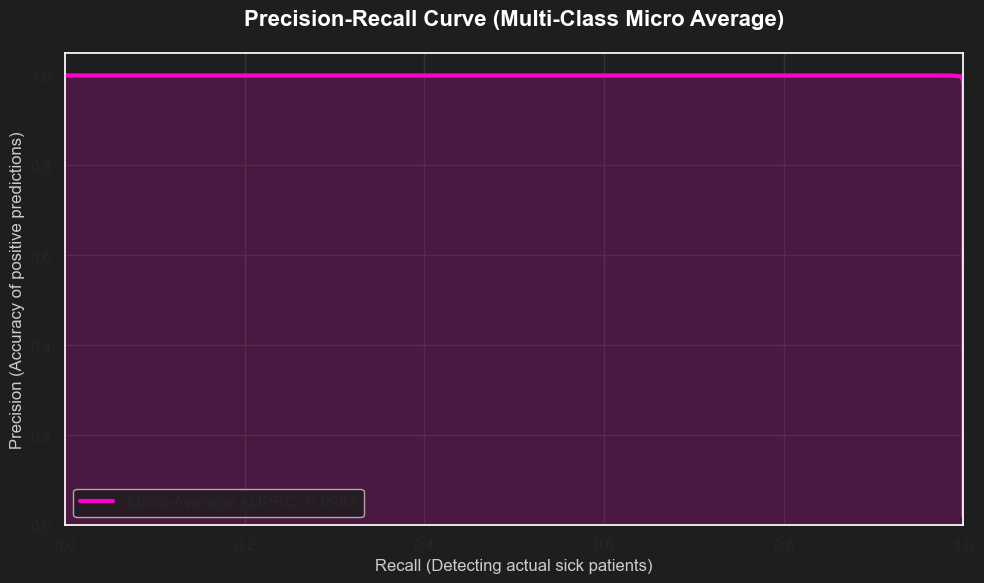

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
import seaborn as sns

# ... [Your previous evaluation and AUPRC printing code] ...

print("📊 Generating Precision-Recall Curve graph...")

# 1. Flatten the matrices for Micro-Averaging
# .ravel() takes the [1024, 41] matrix and flattens it into a single massive 1D array
y_true_flat = y_true_bin.ravel()
y_probs_flat = np.array(all_probabilities).ravel()

# 2. Calculate the exact points for the curve
precision, recall, _ = precision_recall_curve(y_true_flat, y_probs_flat)

# 3. Set up the Enterprise Dark Theme (Matching your Loss Curve)
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#1e1e1e", "figure.facecolor": "#1e1e1e", "grid.color": "#333333"})

# 4. Create the plot
plt.figure(figsize=(10, 6))

# Plot the PR line
plt.plot(recall, precision, color="#ff00cc", linewidth=3, label=f'Micro-Average AUPRC: {macro_auprc:.4f}')

# Fill the area under the curve to make it look professional
plt.fill_between(recall, precision, alpha=0.2, color="#ff00cc")

# 5. Add professional labels
plt.title("Precision-Recall Curve (Multi-Class Micro Average)", fontsize=16, color="white", pad=20, fontweight="bold")
plt.xlabel("Recall (Detecting actual sick patients)", fontsize=12, color="#cccccc")
plt.ylabel("Precision (Accuracy of positive predictions)", fontsize=12, color="#cccccc")

# Lock the axes to 0-1 (since it's percentages)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower left", fontsize=12)

# 6. Save the image to your disk
plt.tight_layout()
plt.savefig("pr_curve.png", dpi=300, bbox_inches='tight')
print("✅ Saved pr_curve.png!")